## Sign Language Detection Using DETR (Detection Transformer)


## Setup and Environment Configuration

In [1]:
# Check if GPU is available and set random seeds for reproducibility
import torch
import numpy as np
import random
import os

# Set seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Check GPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()



CUDA Available: True
GPU Name: Tesla T4
GPU Memory: 15.83 GB


In [2]:
from google.colab import drive
drive.flush_and_unmount()


Drive not mounted, so nothing to flush and unmount.


In [3]:
# !rm -rf /root/.config/Google


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive/SignDETR-VSL


checkpoints  dataset.zip  logs	models	results


In [6]:
!cp /content/drive/MyDrive/SignDETR-VSL/dataset.zip /content/
!unzip -q /content/dataset.zip -d /content/SignDETR-VSL


In [7]:
!find /content/SignDETR-VSL -maxdepth 2 -type d


/content/SignDETR-VSL
/content/SignDETR-VSL/valid
/content/SignDETR-VSL/valid/labels
/content/SignDETR-VSL/valid/images
/content/SignDETR-VSL/train
/content/SignDETR-VSL/train/labels
/content/SignDETR-VSL/train/images
/content/SignDETR-VSL/test
/content/SignDETR-VSL/test/labels
/content/SignDETR-VSL/test/images


In [8]:
import os

ROOT = "/content/SignDETR-VSL"
splits = ["train", "valid", "test"]

def count_files(path, exts):
    return len([f for f in os.listdir(path) if f.lower().endswith(exts)])

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    n_imgs = count_files(img_dir, (".jpg", ".png", ".jpeg"))
    n_lbls = count_files(lbl_dir, (".txt",))

    print(f"{split.upper():5} | images: {n_imgs:5} | labels: {n_lbls:5}")


TRAIN | images:  8832 | labels:  8832
VALID | images:   969 | labels:   969
TEST  | images:   464 | labels:   464


In [9]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [10]:
from collections import Counter
import numpy as np
import os

all_classes = Counter()
boxes_wh = []
objs_per_image = []

for split in ["train", "valid"]:
    lbl_dir = f"{ROOT}/{split}/labels"

    for f in os.listdir(lbl_dir):
        if not f.endswith(".txt"):
            continue

        with open(os.path.join(lbl_dir, f)) as file:
            lines = file.readlines()

        valid_boxes = 0

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))

            # --- POLYGON → BBOX ---
            if len(coords) > 4:
                xs = coords[0::2]
                ys = coords[1::2]

                x_min, x_max = min(xs), max(xs)
                y_min, y_max = min(ys), max(ys)

                w = x_max - x_min
                h = y_max - y_min
                x_c = x_min + w / 2
                y_c = y_min + h / 2
            else:
                x_c, y_c, w, h = coords

            # clamp
            x_min = np.clip(x_c - w/2, 0.0, 1.0)
            y_min = np.clip(y_c - h/2, 0.0, 1.0)
            x_max = np.clip(x_c + w/2, 0.0, 1.0)
            y_max = np.clip(y_c + h/2, 0.0, 1.0)

            w = x_max - x_min
            h = y_max - y_min

            if w > 0.001 and h > 0.001:
                all_classes[cls_id] += 1
                boxes_wh.append([w, h])
                valid_boxes += 1

        objs_per_image.append(valid_boxes)


In [11]:
print("Number of classes:", len(all_classes))
print("Class distribution:")
for k, v in sorted(all_classes.items()):
    print(f"Class {k}: {v} objects")

boxes_wh = np.array(boxes_wh)

print("\nObjects per image:")
print("Min:", min(objs_per_image))
print("Max:", max(objs_per_image))
print("Mean:", round(np.mean(objs_per_image), 2))

print("\n📦 Bounding box size (normalized):")
print("Width : min", boxes_wh[:,0].min(), "max", boxes_wh[:,0].max(), "mean", boxes_wh[:,0].mean())
print("Height: min", boxes_wh[:,1].min(), "max", boxes_wh[:,1].max(), "mean", boxes_wh[:,1].mean())


Number of classes: 22
Class distribution:
Class 0: 439 objects
Class 1: 445 objects
Class 2: 460 objects
Class 3: 887 objects
Class 4: 349 objects
Class 5: 452 objects
Class 6: 477 objects
Class 7: 451 objects
Class 8: 452 objects
Class 9: 359 objects
Class 10: 414 objects
Class 11: 418 objects
Class 12: 417 objects
Class 13: 412 objects
Class 14: 428 objects
Class 15: 437 objects
Class 16: 400 objects
Class 17: 456 objects
Class 18: 436 objects
Class 19: 416 objects
Class 20: 377 objects
Class 21: 419 objects

Objects per image:
Min: 1
Max: 1
Mean: 1.0

📦 Bounding box size (normalized):
Width : min 0.54901828125 max 1.0 mean 0.8894816990315083
Height: min 0.7126109281250002 max 1.0 mean 0.9372661762320171


In [12]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

ROOT = "/content/SignDETR-VSL"

def show_images(split="train", n=5):
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    images = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    samples = random.sample(images, min(n, len(images)))

    for img_name in samples:
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(
            lbl_dir,
            os.path.splitext(img_name)[0] + ".txt"
        )

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape

        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls_id = int(parts[0])
                coords = list(map(float, parts[1:]))

                # ---- POLYGON → BBOX ----
                if len(coords) > 4:
                    xs = coords[0::2]
                    ys = coords[1::2]
                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)
                    bw = x_max - x_min
                    bh = y_max - y_min
                    cx = x_min + bw / 2
                    cy = y_min + bh / 2
                else:
                    cx, cy, bw, bh = coords

                # YOLO (normalized) → pixel
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)

                # clamp
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w - 1, x2), min(h - 1, y2)

                if x2 > x1 and y2 > y1:
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(
                        img,
                        f"{cls_id}",
                        (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1,
                        cv2.LINE_AA
                    )

        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{split} | {img_name}")
        plt.axis("off")
        plt.show()


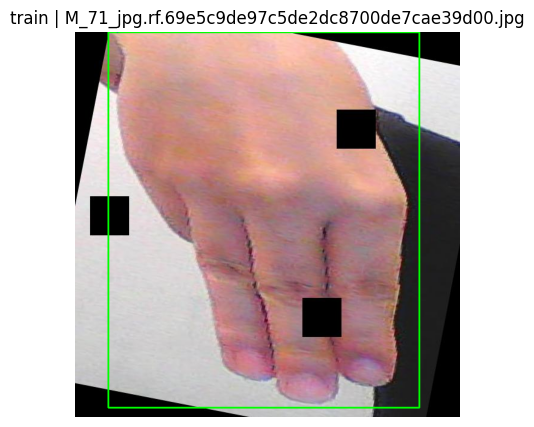

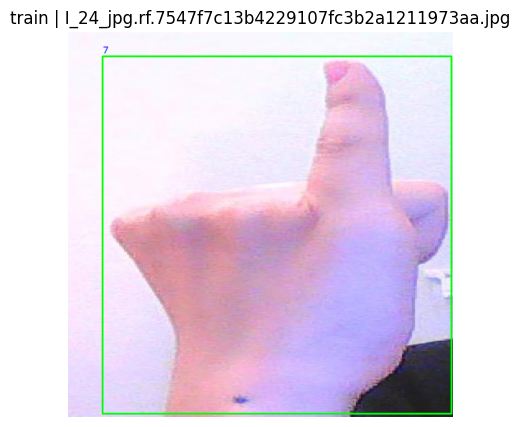

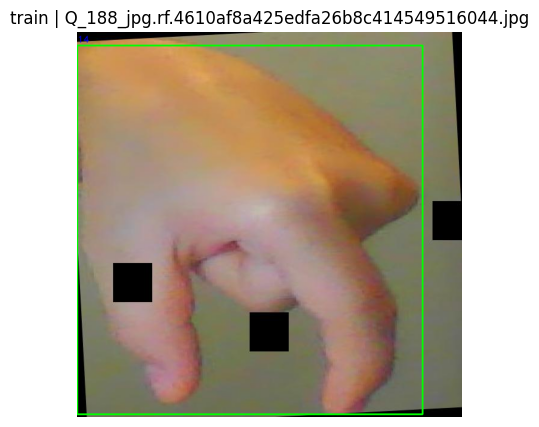

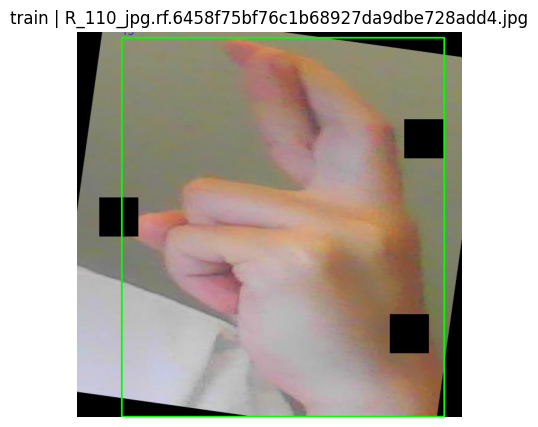

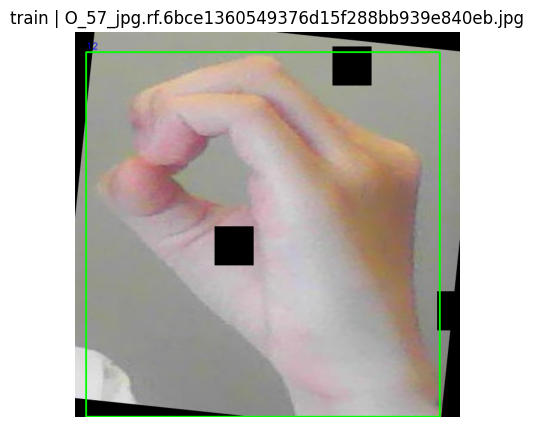

In [13]:
show_images("train", n=5)


In [14]:
def normalize_class(cls):
    if cls == "DD":
        return "D"
    return cls


In [15]:
def get_classes_from_filenames(images_dir):
    classes = set()
    for fname in os.listdir(images_dir):
        if not fname.lower().endswith((".jpg", ".png", ".jpeg")):
            continue
        raw_cls = fname.split("_")[0]
        cls = normalize_class(raw_cls)
        classes.add(cls)
    return sorted(list(classes))


In [16]:
CLASSES = get_classes_from_filenames("/content/SignDETR-VSL/train/images")
print(CLASSES)
print("Number of classes:", len(CLASSES))


['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']
Number of classes: 22


## Section 3: Install Library

In [17]:
import subprocess
import sys

packages = [
    'albumentations',
    'colorama',
    'rich',
    'torchinfo',
    'scipy'
]

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("All packages installed successfully!")

# Verify PyTorch installation
print(f"\nPyTorch version: {torch.__version__}")
print(f"TorchVision version: {__import__('torchvision').__version__}")

Installing required packages...
All packages installed successfully!

PyTorch version: 2.9.0+cu126
TorchVision version: 0.24.0+cu126


## Section 4: Define Core Classes and Utility Functions

In [18]:
# Define DETR Model
import torch
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights
#
import math

def _get_1d_sincos_pos_embed(length: int, dim: int, temperature: float = 10000.0, device=None):
    assert dim % 2 == 0
    position = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, device=device, dtype=torch.float32) * (-math.log(temperature) / dim)
    )
    pe = torch.zeros(length, dim, device=device, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

def build_2d_sincos_position_embedding(height: int, width: int, dim: int, device=None):
    assert dim % 2 == 0, "positional dim must be even"
    dim_half = dim // 2
    pe_y = _get_1d_sincos_pos_embed(height, dim_half, device=device)
    pe_x = _get_1d_sincos_pos_embed(width, dim_half, device=device)
    pos = torch.zeros(height, width, dim, device=device, dtype=torch.float32)
    pos[:, :, :dim_half] = pe_y[:, None, :].expand(-1, width, -1)
    pos[:, :, dim_half:] = pe_x[None, :, :].expand(height, -1, -1)
    pos = pos.view(1, height * width, dim)
    return pos

class DETR(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, nheads=8,
                 num_encoder_layers=1, num_decoder_layers=1, num_queries=25):
        super().__init__()

        # ResNet-50 backbone
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Identity()

        # Conversion layer
        self.conv = nn.Conv2d(2048, hidden_dim, 1)

        # Transformer
        self.transformer = nn.Transformer(
            hidden_dim, nheads, num_encoder_layers, num_decoder_layers,
            batch_first=True, dropout=0.1)

        # Prediction heads
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)
        self.linear_bbox = nn.Linear(hidden_dim, 4)

        # Query embeddings
        self.num_queries = num_queries
        self.query_pos = nn.Parameter(torch.randn(self.num_queries, hidden_dim))

        # Normalizations
        self.norm_src = nn.LayerNorm(hidden_dim)
        self.norm_tgt = nn.LayerNorm(hidden_dim)

    def forward(self, inputs):
        x = self.backbone.conv1(inputs)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        feat = self.conv(x)
        bsz, d_model, Hf, Wf = feat.shape
        src = feat.flatten(2).permute(0, 2, 1)

        pos = build_2d_sincos_position_embedding(Hf, Wf, d_model, device=feat.device)
        src = self.norm_src(src + pos)

        tgt = torch.zeros(bsz, self.num_queries, d_model, device=feat.device)
        query_pos = self.query_pos.unsqueeze(0).expand(bsz, -1, -1)
        tgt = self.norm_tgt(tgt + query_pos)

        hs = self.transformer(src=src, tgt=tgt)

        return {
            'pred_logits': self.linear_class(hs),
            'pred_boxes': self.linear_bbox(hs).sigmoid()
        }

print("DETR model defined")

DETR model defined


In [19]:
# Define utility functions for boxes and data
from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def box_cxcywh_to_xyxy(x):
    """Convert boxes from (cx, cy, w, h) to (x1, y1, x2, y2)"""
    x0, y0, w, h = x.unbind(-1)
    b = [(x0 - 0.5 * w), (y0 - 0.5 * h), (x0 + 0.5 * w), (y0 + 0.5 * h)]
    return torch.stack(b, dim=-1)

def generalized_box_iou(boxes1, boxes2):
    """Compute the IoU between boxes"""
    assert (boxes1[:, 2:] >= boxes1[:, :2]).all()
    assert (boxes2[:, 2:] >= boxes2[:, :2]).all()

    iou, union = box_iou(boxes1, boxes2)

    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    enc_area = wh[:, :, 0] * wh[:, :, 1]

    return iou - (enc_area - union) / enc_area

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    iou = inter / union
    return iou, union

def rescale_bboxes(out_bbox, size):
    """Rescale bounding boxes from normalized coordinates"""
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=b.dtype, device=b.device)
    return b

def stacker(batch):
    """Stack batch items"""
    images, targets = [], []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return torch.stack(images), targets

def get_classes():
    return CLASSES

def get_colors():
    return [(0, 255, 0), (255, 0, 0), (0, 0, 255)]

print("Utility functions defined")

Utility functions defined


In [20]:
# Define Loss Functions
class HungarianMatcher(nn.Module):
    """Hungarian matching for DETR"""
    def __init__(self, weight_dict: dict):
        super().__init__()
        self.class_weighting = weight_dict.get('class_weighting')
        self.bbox_weighting = weight_dict.get('bbox_weighting')
        self.giou_weighting = weight_dict.get('giou_weighting')

    @torch.no_grad()
    def forward(self, yhat, y):
        indices = []
        for batch_idx, target in enumerate(y):
            batch_logits = yhat["pred_logits"][batch_idx]
            batch_boxes = yhat["pred_boxes"][batch_idx]
            batch_prob = batch_logits.softmax(-1)

            tgt_labels = target["labels"].to(torch.long)
            tgt_boxes = target["boxes"].to(batch_boxes.dtype)

            cost_class = -batch_prob[:, tgt_labels]
            cost_bbox = torch.cdist(batch_boxes, tgt_boxes, p=1)
            cost_giou = -generalized_box_iou(
                box_cxcywh_to_xyxy(batch_boxes),
                box_cxcywh_to_xyxy(tgt_boxes)
            )

            C_batch = (self.bbox_weighting * cost_bbox +
                      self.class_weighting * cost_class +
                      self.giou_weighting * cost_giou).cpu()

            ii, jj = linear_sum_assignment(C_batch)
            indices.append(
                (torch.as_tensor(ii, dtype=torch.int64), torch.as_tensor(jj, dtype=torch.int64))
            )
        return indices

class DETRLoss(nn.Module):
    """DETR Loss computation"""
    def __init__(self, num_classes, matcher, weight_dict, eos_coef):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef
        empty_weight = torch.ones(self.num_classes + 1)
        empty_weight[-1] = self.eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def classification_loss(self, yhat, y, indices):
        src_logits = yhat['pred_logits']
        idx = self.get_matched_query_indices(indices)
        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(y, indices)])
        target_classes = torch.full(src_logits.shape[:2], self.num_classes,
                                  dtype=torch.int64, device=src_logits.device)
        target_classes[idx] = target_classes_o
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, self.empty_weight)
        return {'loss_ce': loss_ce}

    def box_loss(self, yhat, y, indices, num_boxes):
        idx = self.get_matched_query_indices(indices)
        src_boxes = yhat['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(y, indices)], dim=0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none')
        loss_bbox_sum = loss_bbox.sum() / num_boxes

        loss_giou = 1 - torch.diag(generalized_box_iou(
            box_cxcywh_to_xyxy(src_boxes),
            box_cxcywh_to_xyxy(target_boxes)))
        loss_giou_sum = loss_giou.sum() / num_boxes

        return {'loss_bbox': loss_bbox_sum, 'loss_giou': loss_giou_sum}

    def get_matched_query_indices(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def forward(self, yhat, y):
        indices = self.matcher(yhat, y)
        device = next(iter(yhat.values())).device
        y = [{'labels': t['labels'].to(torch.long), 'boxes': t['boxes'].to(torch.float32)} for t in y]

        num_boxes = sum(len(t["labels"]) for t in y)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=device).clamp(min=1)

        return {
            'labels': self.classification_loss(yhat, y, indices),
            'boxes': self.box_loss(yhat, y, indices, num_boxes)
        }

print("Loss functions defined")

Loss functions defined


In [21]:
import os
import glob
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DETRData(Dataset):
    def __init__(self, path, train=True):
        super().__init__()
        self.path = path
        self.labels_path = os.path.join(self.path, 'labels')
        self.images_path = os.path.join(self.path, 'images')

        if os.path.exists(self.labels_path):
            self.label_files = os.listdir(self.labels_path)
            self.labels = list(filter(lambda x: x.endswith('.txt'), self.label_files))
        else:
            self.labels = []
            print(f"Cảnh báo: Không tìm thấy thư mục labels tại {self.labels_path}")

        self.train = train

    def safe_transform(self, image, bboxes, labels, max_attempts=50):
        # Định nghĩa transform
        self.transform = A.Compose(
            [
                A.Resize(500, 500),
                *([A.RandomCrop(width=224, height=224, p=0.33)] if self.train else []),
                A.Resize(224, 224),
                *([A.HorizontalFlip(p=0.5)] if self.train else []),
                *([A.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5, p=0.5)] if self.train else []),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ],
            # check_each_transform=False giúp bỏ qua lỗi nhỏ, min_visibility loại bỏ box quá nhỏ
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.1)
        )

        for attempt in range(max_attempts):
            try:
                transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
                if len(transformed['bboxes']) > 0:
                    return transformed
            except Exception as e:
                # Nếu lỗi augmentation, thử lại
                continue

        # Fallback: Chỉ resize và normalize nếu augment lỗi
        fallback = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        return fallback(image=image, bboxes=bboxes, class_labels=labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_filename = self.labels[idx]
        label_path = os.path.join(self.labels_path, label_filename)

        # Tìm ảnh (xử lý lỗi tên file Roboflow)
        image_name_base = os.path.splitext(label_filename)[0]
        search_pattern = os.path.join(self.images_path, image_name_base + "*")
        found_images = glob.glob(search_pattern)

        if len(found_images) == 0:
            return self.__getitem__((idx + 1) % len(self))

        image_path = found_images[0]

        try:
            img = Image.open(image_path).convert('RGB')
            w_img, h_img = img.size # Kích thước ảnh gốc

            with open(label_path, 'r') as f:
                annotations = f.readlines()

            class_labels = []
            bounding_boxes = []

            for annotation in annotations:
                parts = annotation.strip().split()
                if len(parts) < 5: continue

                cls_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]

                # ---  POLYGON -> BBOX ---
                if len(coords) > 4:

                    xs = coords[0::2]
                    ys = coords[1::2]

                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)

                    w = x_max - x_min
                    h = y_max - y_min
                    x_c = x_min + w / 2
                    y_c = y_min + h / 2
                else:

                    x_c, y_c, w, h = coords


                x_min = np.clip(x_c - w/2, 0.0, 1.0)
                y_min = np.clip(y_c - h/2, 0.0, 1.0)
                x_max = np.clip(x_c + w/2, 0.0, 1.0)
                y_max = np.clip(y_c + h/2, 0.0, 1.0)


                w = x_max - x_min
                h = y_max - y_min
                x_c = x_min + w/2
                y_c = y_min + h/2


                if w > 0.001 and h > 0.001:
                    class_labels.append(cls_id)
                    bounding_boxes.append([x_c, y_c, w, h])

            if len(class_labels) == 0:
                return self.__getitem__((idx + 1) % len(self))

            class_labels = np.array(class_labels)
            bounding_boxes = np.array(bounding_boxes)

            # Augmentation
            augmented = self.safe_transform(image=np.array(img), bboxes=bounding_boxes, labels=class_labels)

            augmented_img_tensor = augmented['image']
            augmented_bounding_boxes = np.array(augmented['bboxes'])
            augmented_classes = augmented['class_labels']

            if len(augmented_bounding_boxes) == 0:
                 return self.__getitem__((idx + 1) % len(self))

            labels = torch.tensor(augmented_classes, dtype=torch.long)
            boxes = torch.tensor(augmented_bounding_boxes, dtype=torch.float32)

            return augmented_img_tensor, {'labels': labels, 'boxes': boxes}

        except Exception as e:
            print(f"Bỏ qua file lỗi {label_filename}: {str(e)}")
            return self.__getitem__((idx + 1) % len(self))

print("Dataset class updated: Supports Polygons & Auto-fix coordinates.")

Dataset class updated: Supports Polygons & Auto-fix coordinates.


## Initialize Model, Data Loaders, and Training Components

In [22]:
DATA_DIR = "/content/SignDETR-VSL/"


In [23]:
# Initialize training components
from torch import optim
from torch.utils.data import DataLoader
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training configuration
num_classes = 22
batch_size = 128
learning_rate = 1e-5
num_epochs = 100
checkpoint_interval = 5

# Create datasets and dataloaders
print("Loading datasets...")
train_dataset = DETRData(os.path.join(DATA_DIR, 'train'), train=True)
valid_dataset = DETRData(os.path.join(DATA_DIR, 'valid'), train=False)
test_dataset = DETRData(os.path.join(DATA_DIR, 'test'), train=False)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=stacker, drop_last=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Using device: cuda
Loading datasets...
Train samples: 8832
Valid samples: 969
Test samples: 464


In [24]:
# Initialize model, optimizer, loss, and scheduler
print("Initializing model and training components...")

# Create model
model = DETR(num_classes=num_classes, hidden_dim=256, nheads=8,
             num_encoder_layers=1, num_decoder_layers=1, num_queries=25)
model = model.to(device)
print(f"Model moved to {device}")

# Loss weights
weights = {
    'class_weighting': 1.0,
    'bbox_weighting': 5.0,
    'giou_weighting': 2.0
}

# Create matcher and loss function
matcher = HungarianMatcher(weights)
criterion = DETRLoss(num_classes=num_classes, matcher=matcher,
                     weight_dict=weights, eos_coef=0.1)
criterion = criterion.to(device)
# Optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("Model initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Initializing model and training components...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 52.9MB/s]


Model moved to cuda
Model initialized successfully!
Total parameters: 26,941,787
Trainable parameters: 26,941,787


## Section 6: Training Loop with Validation

In [25]:
import os
import shutil
import time
import torch
import csv
from tqdm import tqdm

CHECKPOINT_DIR = '/content/SignDETR/checkpoints'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/SignDETR-VSL/checkpoints'
LOG_FILENAME = 'training_log.csv'

local_log_path = os.path.join(CHECKPOINT_DIR, LOG_FILENAME)
drive_log_path = os.path.join(DRIVE_CHECKPOINT_DIR, LOG_FILENAME)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
print(f"Thư mục lưu trên Drive: {DRIVE_CHECKPOINT_DIR}")


with open(local_log_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Epoch', 'Train_Loss', 'Valid_Loss', 'Test_Loss', 'Time(s)'])
shutil.copy(local_log_path, drive_log_path)


Thư mục lưu trên Drive: /content/drive/MyDrive/SignDETR-VSL/checkpoints


'/content/drive/MyDrive/SignDETR-VSL/checkpoints/training_log.csv'

In [26]:
# train_losses = []
# valid_losses = []
# test_losses = []
# best_valid_loss = float('inf')
# checkpoint_interval = 1

# start_epoch = 1

# print("🚀 Starting training from scratch (Epoch 1)...\n")
# train_batches = len(train_dataloader)
# valid_batches = len(valid_dataloader)
# test_batches = len(test_dataloader)
# num_epochs = 100
# try:
#     for epoch in range(start_epoch, num_epochs + 1):
#         start_time = time.time()

#         # ================= TRAIN =================
#         model.train()
#         train_epoch_loss = 0.0

#         train_pbar = tqdm(enumerate(train_dataloader), total=train_batches, desc=f"Epoch {epoch}/{num_epochs} [TRAIN]")

#         for batch_idx, (X, y) in train_pbar:
#             X = X.to(device)
#             y = [{k: v.to(device) for k, v in t.items()} for t in y]

#             try:
#                 optimizer.zero_grad()
#                 yhat = model(X)
#                 loss_dict = criterion(yhat, y)
#                 losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                           loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                           loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])

#                 train_epoch_loss += losses.item()
#                 losses.backward()
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
#                 optimizer.step()

#                 train_pbar.set_postfix({'loss': f"{train_epoch_loss/(batch_idx+1):.4f}"})

#             except Exception as e:
#                 print(f"\nError in train batch {batch_idx}: {str(e)}")
#                 continue

#         scheduler.step()
#         avg_train_loss = train_epoch_loss / train_batches
#         train_losses.append(avg_train_loss)

#         # ================= VALID =================
#         model.eval()
#         valid_epoch_loss = 0.0
#         with torch.no_grad():
#             valid_pbar = tqdm(enumerate(valid_dataloader), total=valid_batches, desc=f"Epoch {epoch}/{num_epochs} [VALID]")
#             for batch_idx, (X, y) in valid_pbar:
#                 X = X.to(device)
#                 y = [{k: v.to(device) for k, v in t.items()} for t in y]
#                 try:
#                     yhat = model(X)
#                     loss_dict = criterion(yhat, y)
#                     losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                               loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                               loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])
#                     valid_epoch_loss += losses.item()
#                     valid_pbar.set_postfix({'loss': f"{valid_epoch_loss/(batch_idx+1):.4f}"})
#                 except Exception as e:
#                     continue

#         avg_valid_loss = valid_epoch_loss / valid_batches
#         valid_losses.append(avg_valid_loss)

#         # ================= TEST =================
#         test_epoch_loss = 0.0
#         with torch.no_grad():
#             test_pbar = tqdm(enumerate(test_dataloader), total=test_batches, desc=f"Epoch {epoch}/{num_epochs} [TEST]")
#             for batch_idx, (X, y) in test_pbar:
#                 X = X.to(device)
#                 y = [{k: v.to(device) for k, v in t.items()} for t in y]
#                 try:
#                     yhat = model(X)
#                     loss_dict = criterion(yhat, y)
#                     losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                               loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                               loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])
#                     test_epoch_loss += losses.item()
#                     test_pbar.set_postfix({'loss': f"{test_epoch_loss/(batch_idx+1):.4f}"})
#                 except Exception as e:
#                     continue

#         avg_test_loss = test_epoch_loss / test_batches
#         test_losses.append(avg_test_loss)

#         # Thời gian chạy epoch
#         epoch_duration = time.time() - start_time

#         # ================= LOGGING  =================
#         print(f"\nSummary Epoch {epoch}: Train: {avg_train_loss:.4f} | Valid: {avg_valid_loss:.4f} | Test: {avg_test_loss:.4f}")

#         with open(local_log_path, mode='a', newline='') as file:
#             writer = csv.writer(file)
#             writer.writerow([epoch, f"{avg_train_loss:.4f}", f"{avg_valid_loss:.4f}", f"{avg_test_loss:.4f}", f"{epoch_duration:.2f}"])

#         try:
#             shutil.copy(local_log_path, drive_log_path)
#         except Exception as e:
#             print(f"Không thể update log lên Drive: {e}")

#         checkpoint_dict = {
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'scheduler_state_dict': scheduler.state_dict(),
#             'loss': avg_valid_loss,
#             'num_classes': num_classes
#         }

#         if avg_valid_loss < best_valid_loss:
#             best_valid_loss = avg_valid_loss
#             best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
#             torch.save(checkpoint_dict, best_path)
#             shutil.copy(best_path, os.path.join(DRIVE_CHECKPOINT_DIR, 'best_model.pt'))
#             print(f"⭐ Đã lưu Best Model lên Drive (Loss: {best_valid_loss:.4f})")

#         if epoch % checkpoint_interval == 0:
#             filename = f"checkpoint_epoch_{epoch}.pt"
#             local_path = os.path.join(CHECKPOINT_DIR, filename)
#             drive_path = os.path.join(DRIVE_CHECKPOINT_DIR, filename)
# #
#             torch.save(checkpoint_dict, local_path)
#             try:
#                 shutil.copy(local_path, drive_path)
#                 print(f"Đã backup checkpoint epoch {epoch} lên Drive.")
#             except Exception as e:
#                 print(f"Lỗi copy checkpoint lên Drive: {e}")

# except KeyboardInterrupt:
#     print("\nTraining interrupted. Saving emergency checkpoint...")
#     checkpoint_dict['epoch'] = epoch # Update epoch dừng lại
#     torch.save(checkpoint_dict, os.path.join(DRIVE_CHECKPOINT_DIR, 'interrupted_model.pt'))
#     print("Saved interrupted_model.pt to Drive")

In [27]:
# import os
# import torch
# import shutil
# import time
# import csv
# from tqdm import tqdm

# train_losses = []
# valid_losses = []
# test_losses = []
# best_valid_loss = float('inf')
# checkpoint_interval = 1
# start_epoch = 1

# resume_filename = "checkpoint_epoch_18.pt"
# resume_path = os.path.join(DRIVE_CHECKPOINT_DIR, resume_filename)

# if os.path.exists(resume_path):

#     # Load checkpoint
#     checkpoint = torch.load(resume_path, map_location=device)

#     # 1. Load trọng số Model
#     model.load_state_dict(checkpoint['model_state_dict'])

#     # 2. Load Optimizer (để giữ learning rate, momentum...)
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

#     # 3. Load Scheduler (nếu có)
#     if 'scheduler_state_dict' in checkpoint:
#         scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

#     # 4. Cập nhật Epoch bắt đầu (Epoch đã lưu + 1)
#     start_epoch = checkpoint['epoch'] + 1

#     # 5. Cập nhật Best Loss để so sánh tiếp
#     if 'loss' in checkpoint:
#         best_valid_loss = checkpoint['loss']

#     print(f"🚀 THÀNH CÔNG! Tiếp tục train từ Epoch {start_epoch}")
# else:
#     print(f"⚠️ Không tìm thấy file {resume_filename}. Sẽ train từ đầu (Epoch 1).")
# # ==============================================================================


# print(f"\n🚀 Starting training process... (Total: {num_epochs} epochs)")
# train_batches = len(train_dataloader)
# valid_batches = len(valid_dataloader)
# test_batches = len(test_dataloader)

# try:
#     for epoch in range(start_epoch, num_epochs + 1):
#         start_time = time.time()

#         # ================= TRAIN =================
#         model.train()
#         train_epoch_loss = 0.0

#         train_pbar = tqdm(enumerate(train_dataloader), total=train_batches, desc=f"Epoch {epoch}/{num_epochs} [TRAIN]")

#         for batch_idx, (X, y) in train_pbar:
#             X = X.to(device)
#             y = [{k: v.to(device) for k, v in t.items()} for t in y]

#             try:
#                 optimizer.zero_grad()
#                 yhat = model(X)
#                 loss_dict = criterion(yhat, y)
#                 losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                           loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                           loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])

#                 train_epoch_loss += losses.item()
#                 losses.backward()
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
#                 optimizer.step()

#                 train_pbar.set_postfix({'loss': f"{train_epoch_loss/(batch_idx+1):.4f}"})

#             except Exception as e:
#                 print(f"\nError in train batch {batch_idx}: {str(e)}")
#                 continue

#         scheduler.step()
#         avg_train_loss = train_epoch_loss / train_batches
#         train_losses.append(avg_train_loss)

#         # ================= VALID =================
#         model.eval()
#         valid_epoch_loss = 0.0
#         with torch.no_grad():
#             valid_pbar = tqdm(enumerate(valid_dataloader), total=valid_batches, desc=f"Epoch {epoch}/{num_epochs} [VALID]")
#             for batch_idx, (X, y) in valid_pbar:
#                 X = X.to(device)
#                 y = [{k: v.to(device) for k, v in t.items()} for t in y]
#                 try:
#                     yhat = model(X)
#                     loss_dict = criterion(yhat, y)
#                     losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                               loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                               loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])
#                     valid_epoch_loss += losses.item()
#                     valid_pbar.set_postfix({'loss': f"{valid_epoch_loss/(batch_idx+1):.4f}"})
#                 except Exception as e:
#                     continue

#         avg_valid_loss = valid_epoch_loss / valid_batches
#         valid_losses.append(avg_valid_loss)

#         # ================= TEST =================
#         test_epoch_loss = 0.0
#         with torch.no_grad():
#             test_pbar = tqdm(enumerate(test_dataloader), total=test_batches, desc=f"Epoch {epoch}/{num_epochs} [TEST]")
#             for batch_idx, (X, y) in test_pbar:
#                 X = X.to(device)
#                 y = [{k: v.to(device) for k, v in t.items()} for t in y]
#                 try:
#                     yhat = model(X)
#                     loss_dict = criterion(yhat, y)
#                     losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
#                               loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
#                               loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])
#                     test_epoch_loss += losses.item()
#                     test_pbar.set_postfix({'loss': f"{test_epoch_loss/(batch_idx+1):.4f}"})
#                 except Exception as e:
#                     continue

#         avg_test_loss = test_epoch_loss / test_batches
#         test_losses.append(avg_test_loss)

#         # Thời gian chạy epoch
#         epoch_duration = time.time() - start_time

#         # ================= LOGGING  =================
#         print(f"\nSummary Epoch {epoch}: Train: {avg_train_loss:.4f} | Valid: {avg_valid_loss:.4f} | Test: {avg_test_loss:.4f}")

#         # Ghi log CSV
#         with open(local_log_path, mode='a', newline='') as file:
#             writer = csv.writer(file)
#             writer.writerow([epoch, f"{avg_train_loss:.4f}", f"{avg_valid_loss:.4f}", f"{avg_test_loss:.4f}", f"{epoch_duration:.2f}"])

#         # Backup Log lên Drive
#         try:
#             shutil.copy(local_log_path, drive_log_path)
#         except Exception as e:
#             print(f"Không thể update log lên Drive: {e}")

#         # Chuẩn bị dữ liệu để lưu checkpoint
#         checkpoint_dict = {
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'scheduler_state_dict': scheduler.state_dict(),
#             'loss': avg_valid_loss,
#             'num_classes': num_classes
#         }

#         # 1. Lưu Best Model
#         if avg_valid_loss < best_valid_loss:
#             best_valid_loss = avg_valid_loss
#             best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
#             torch.save(checkpoint_dict, best_path)
#             # Copy ngay lên Drive
#             shutil.copy(best_path, os.path.join(DRIVE_CHECKPOINT_DIR, 'best_model.pt'))
#             print(f"⭐ Đã lưu Best Model lên Drive (Loss: {best_valid_loss:.4f})")

#         # 2. Lưu Regular Checkpoint (Backup mỗi epoch)
#         if epoch % checkpoint_interval == 0:
#             filename = f"checkpoint_epoch_{epoch}.pt"
#             local_path = os.path.join(CHECKPOINT_DIR, filename)
#             drive_path = os.path.join(DRIVE_CHECKPOINT_DIR, filename)

#             torch.save(checkpoint_dict, local_path)
#             try:
#                 shutil.copy(local_path, drive_path)
#                 print(f"Đã backup checkpoint epoch {epoch} lên Drive.")
#             except Exception as e:
#                 print(f"Lỗi copy checkpoint lên Drive: {e}")



# except KeyboardInterrupt:
#     print("\nTraining interrupted. Saving emergency checkpoint...")
#     checkpoint_dict['epoch'] = epoch
#     torch.save(checkpoint_dict, os.path.join(DRIVE_CHECKPOINT_DIR, 'interrupted_model.pt'))
#     print("Saved interrupted_model.pt to Drive")

In [34]:
import os
import shutil
import time
import torch
import csv
from tqdm import tqdm

RESUME_FROM_CHECKPOINT = True  # Đặt True để tiếp tục, False để train từ đầu
CHECKPOINT_PATH = os.path.join(DRIVE_CHECKPOINT_DIR, 'checkpoint_epoch_26.pt')



# ================== KHỞI TẠO BIẾN ==================
train_losses = []
valid_losses = []
test_losses = []
best_valid_loss = float('inf')
start_epoch = 1

# ================== NẠP CHECKPOINT ==================
if RESUME_FROM_CHECKPOINT and os.path.exists(CHECKPOINT_PATH):
    print(f"Đang nạp checkpoint từ: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    # Khôi phục model state
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Đã nạp model weights")

    # Khôi phục optimizer state
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("Đã nạp optimizer state")

    # Khôi phục scheduler state
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print("Đã nạp scheduler state")

    # Khôi phục epoch và best loss
    start_epoch = checkpoint['epoch'] + 1  # Bắt đầu từ epoch tiếp theo
    best_valid_loss = checkpoint.get('loss', float('inf'))

    print(f"\nCheckpoint Info:")
    print(f"   - Đã train đến: Epoch {checkpoint['epoch']}")
    print(f"   - Best Valid Loss: {best_valid_loss:.4f}")
    print(f"   - Tiếp tục từ: Epoch {start_epoch}")
    print(f"   - Số classes: {checkpoint.get('num_classes', 'N/A')}\n")

    # Nạp lại loss history từ file CSV
    try:
        if os.path.exists(drive_log_path):
            with open(drive_log_path, 'r') as f:
                reader = csv.reader(f)
                header = next(reader)  # Skip header
                for row in reader:
                    if len(row) >= 4:
                        train_losses.append(float(row[1]))
                        valid_losses.append(float(row[2]))
                        test_losses.append(float(row[3]))
            print(f"Đã nạp loss history: {len(train_losses)} epochs\n")
    except Exception as e:
        print(f"Không thể nạp log file: {e}")
        print("   (Sẽ bắt đầu log mới từ đây)\n")
else:
    print("Starting training from scratch (Epoch 1)...\n")

# ================== TRAINING LOOP ==================
train_batches = len(train_dataloader)
valid_batches = len(valid_dataloader)
test_batches = len(test_dataloader)
num_epochs = 100

try:
    for epoch in range(start_epoch, num_epochs + 1):
        start_time = time.time()

        # ================= TRAIN =================
        model.train()
        train_epoch_loss = 0.0

        train_pbar = tqdm(enumerate(train_dataloader), total=train_batches,
                         desc=f"Epoch {epoch}/{num_epochs} [TRAIN]")

        for batch_idx, (X, y) in train_pbar:
            X = X.to(device)
            y = [{k: v.to(device) for k, v in t.items()} for t in y]

            try:
                optimizer.zero_grad()
                yhat = model(X)
                loss_dict = criterion(yhat, y)

                losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
                         loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
                         loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])

                train_epoch_loss += losses.item()
                losses.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
                optimizer.step()

                train_pbar.set_postfix({'loss': f"{train_epoch_loss/(batch_idx+1):.4f}"})

            except Exception as e:
                print(f"\nError in train batch {batch_idx}: {str(e)}")
                continue

        scheduler.step()
        avg_train_loss = train_epoch_loss / train_batches
        train_losses.append(avg_train_loss)

        # ================= VALID =================
        model.eval()
        valid_epoch_loss = 0.0

        with torch.no_grad():
            valid_pbar = tqdm(enumerate(valid_dataloader), total=valid_batches,
                            desc=f"Epoch {epoch}/{num_epochs} [VALID]")

            for batch_idx, (X, y) in valid_pbar:
                X = X.to(device)
                y = [{k: v.to(device) for k, v in t.items()} for t in y]

                try:
                    yhat = model(X)
                    loss_dict = criterion(yhat, y)

                    losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
                             loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
                             loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])

                    valid_epoch_loss += losses.item()
                    valid_pbar.set_postfix({'loss': f"{valid_epoch_loss/(batch_idx+1):.4f}"})

                except Exception as e:
                    continue

        avg_valid_loss = valid_epoch_loss / valid_batches
        valid_losses.append(avg_valid_loss)

        # ================= TEST =================
        test_epoch_loss = 0.0

        with torch.no_grad():
            test_pbar = tqdm(enumerate(test_dataloader), total=test_batches,
                           desc=f"Epoch {epoch}/{num_epochs} [TEST]")

            for batch_idx, (X, y) in test_pbar:
                X = X.to(device)
                y = [{k: v.to(device) for k, v in t.items()} for t in y]

                try:
                    yhat = model(X)
                    loss_dict = criterion(yhat, y)

                    losses = (loss_dict['labels']['loss_ce'] * weights['class_weighting'] +
                             loss_dict['boxes']['loss_bbox'] * weights['bbox_weighting'] +
                             loss_dict['boxes']['loss_giou'] * weights['giou_weighting'])

                    test_epoch_loss += losses.item()
                    test_pbar.set_postfix({'loss': f"{test_epoch_loss/(batch_idx+1):.4f}"})

                except Exception as e:
                    continue

        avg_test_loss = test_epoch_loss / test_batches
        test_losses.append(avg_test_loss)

        epoch_duration = time.time() - start_time

        # ================= LOGGING =================
        print(f"Summary Epoch {epoch}: Train: {avg_train_loss:.4f} | Valid: {avg_valid_loss:.4f} | Test: {avg_test_loss:.4f}")

        with open(local_log_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, f"{avg_train_loss:.4f}", f"{avg_valid_loss:.4f}",
                           f"{avg_test_loss:.4f}", f"{epoch_duration:.2f}"])

        try:
            shutil.copy(local_log_path, drive_log_path)
        except Exception as e:
            print(f"Không thể update log lên Drive: {e}")

        # ================= SAVING CHECKPOINTS =================
        checkpoint_dict = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': avg_valid_loss,
            'num_classes': num_classes
        }

        # Lưu Best Model
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            best_path_local = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
            best_path_drive = os.path.join(DRIVE_CHECKPOINT_DIR, 'best_model.pt')

            torch.save(checkpoint_dict, best_path_local)
            try:
                shutil.copy(best_path_local, best_path_drive)
                print(f"Đã lưu Best Model lên Drive (Loss: {best_valid_loss:.4f})")
            except Exception as e:
                print(f"Lỗi lưu Best Model: {e}")

        # Lưu checkpoint theo epoch
        checkpoint_epoch_local = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pt')
        checkpoint_epoch_drive = os.path.join(DRIVE_CHECKPOINT_DIR, f'checkpoint_epoch_{epoch}.pt')

        torch.save(checkpoint_dict, checkpoint_epoch_local)
        try:
            shutil.copy(checkpoint_epoch_local, checkpoint_epoch_drive)
            print(f"Đã backup checkpoint epoch {epoch} lên Drive.")
        except Exception as e:
            print(f"⚠️ Lỗi backup checkpoint: {e}")

except KeyboardInterrupt:
    print("\n\n⚠️ Training bị ngắt! Đang lưu checkpoint khẩn cấp...")

    emergency_checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': avg_valid_loss if 'avg_valid_loss' in locals() else float('inf'),
        'num_classes': num_classes
    }

    emergency_path = os.path.join(DRIVE_CHECKPOINT_DIR, f'interrupted_epoch_{epoch}.pt')
    torch.save(emergency_checkpoint, emergency_path)
    print(f"Đã lưu checkpoint khẩn cấp: interrupted_epoch_{epoch}.pt")

except Exception as e:
    print(f"\n\nLỗi nghiêm trọng: {str(e)}")
    import traceback
    traceback.print_exc()

print("\nTraining hoàn tất!")
print(f"Best Valid Loss: {best_valid_loss:.4f}")
print(f"Checkpoints đã lưu tại: {DRIVE_CHECKPOINT_DIR}")

Đang nạp checkpoint từ: /content/drive/MyDrive/SignDETR-VSL/checkpoints/checkpoint_epoch_26.pt
Đã nạp model weights
Đã nạp optimizer state
Đã nạp scheduler state

Checkpoint Info:
   - Đã train đến: Epoch 26
   - Best Valid Loss: 1.2317
   - Tiếp tục từ: Epoch 27
   - Số classes: 22

Đã nạp loss history: 0 epochs



Epoch 27/100 [TEST]: 100%|██████████| 3/3 [00:07<00:00,  2.56s/it, loss=1.2005]


Summary Epoch 27: Train: 1.5238 | Valid: 1.2287 | Test: 1.2005
Đã lưu Best Model lên Drive (Loss: 1.2287)
Đã backup checkpoint epoch 27 lên Drive.


Epoch 28/100 [TEST]: 100%|██████████| 3/3 [00:07<00:00,  2.54s/it, loss=1.2106]


Summary Epoch 28: Train: 1.5201 | Valid: 1.2330 | Test: 1.2106
Đã backup checkpoint epoch 28 lên Drive.


...

Epoch 30/100 [TEST]: 100%|██████████| 3/3 [00:06<00:00,  2.10s/it, loss=1.2056]


Summary Epoch 30: Train: 1.5177 | Valid: 1.2312 | Test: 1.2056
Đã backup checkpoint epoch 30 lên Drive.


Epoch 31/100 [TRAIN]:  22%|██▏       | 15/69 [01:14<04:27,  4.95s/it, loss=1.5106]




⚠️ Training bị ngắt! Đang lưu checkpoint khẩn cấp...


KeyboardInterrupt: 

## Section 7: Visualize Training Results

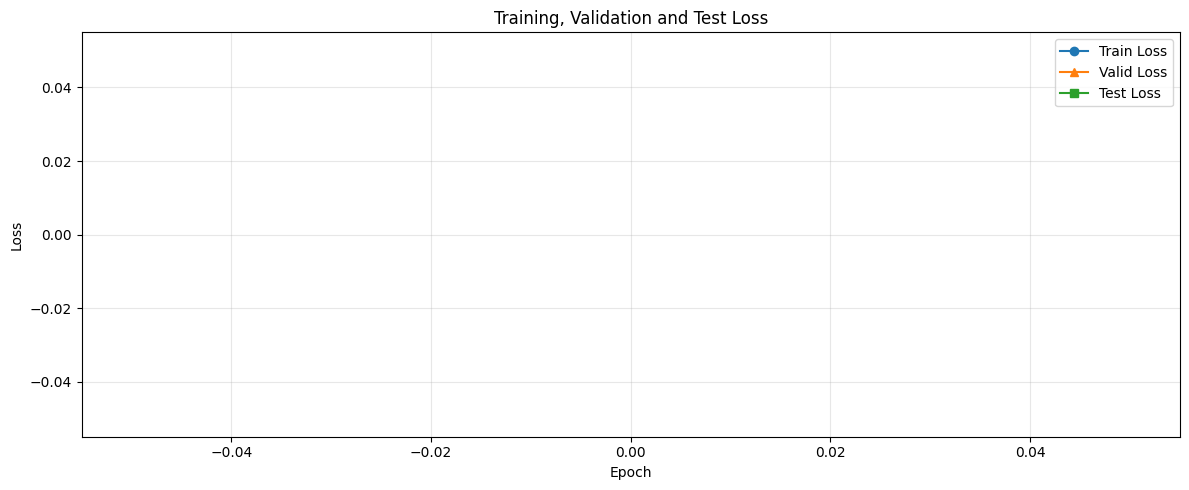

✅ Biểu đồ đã lưu tại: /content/drive/MyDrive/SignDETR-VSL/checkpoints/training_curves.png


In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil

PROJECT_ROOT = '/content/SignDETR'
CHECKPOINT_DIR = '/content/SignDETR/checkpoints'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/SignDETR-VSL/checkpoints'
LOG_FILENAME = 'training_log.csv'

log_path = os.path.join(CHECKPOINT_DIR, LOG_FILENAME)

if os.path.exists(log_path):
    df = pd.read_csv(log_path)

    plt.figure(figsize=(12, 5))
    plt.plot(df['Epoch'], df['Train_Loss'], label='Train Loss', marker='o')
    plt.plot(df['Epoch'], df['Valid_Loss'], label='Valid Loss', marker='^')
    plt.plot(df['Epoch'], df['Test_Loss'], label='Test Loss', marker='s')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training, Validation and Test Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    local_curve_path = os.path.join(CHECKPOINT_DIR, 'training_curves.png')
    plt.savefig(local_curve_path, dpi=100)

    drive_curve_path = os.path.join(DRIVE_CHECKPOINT_DIR, 'training_curves.png')
    shutil.copy(local_curve_path, drive_curve_path)

    plt.show()
    print(f"✅ Biểu đồ đã lưu tại: {drive_curve_path}")
else:
    print("⚠️ Không tìm thấy file log để vẽ biểu đồ.")

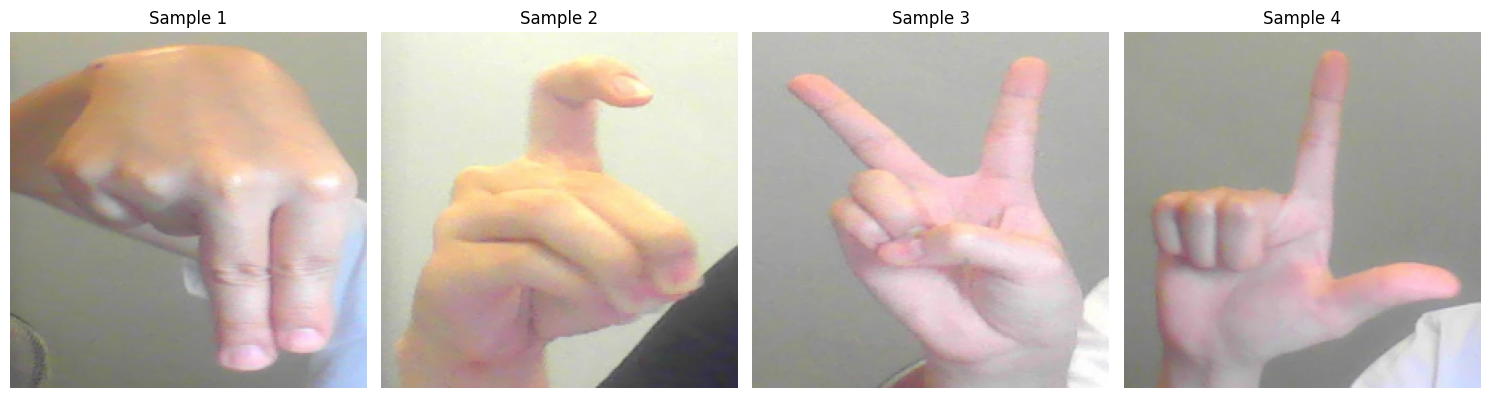

Ảnh dự đoán đã lưu lên Drive.


In [35]:
import numpy as np
import torch

model.eval()
CLASSES = get_classes()

X_test, y_test = next(iter(test_dataloader))
X_test = X_test.to(device)

with torch.no_grad():
    results = model(X_test)

probabilities = results['pred_logits'].softmax(-1)[:, :, :-1]
max_probs, max_classes = probabilities.max(-1)
keep_mask = max_probs > 0.7

num_samples = min(len(X_test), 4)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
if num_samples == 1: axes = [axes] # Xử lý trường hợp chỉ có 1 ảnh

for idx in range(num_samples):
    ax = axes[idx]

    # Chuẩn bị ảnh
    img = X_test[idx].cpu().permute(1, 2, 0).numpy()
    # Denormalize (ImageNet stats)
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(f"Sample {idx+1}")
    ax.axis('off')


    mask = keep_mask[idx]
    if mask.sum() > 0:
        boxes = results['pred_boxes'][idx][mask]
        scaled_boxes = rescale_bboxes(boxes.unsqueeze(0), (224, 224))[0]

        lbls = max_classes[idx][mask].cpu().numpy()
        probs = max_probs[idx][mask].cpu().numpy()

        for box, lbl, prob in zip(scaled_boxes.cpu().numpy(), lbls, probs):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1

            rect = plt.Rectangle((x1, y1), w, h, fill=False, color='green', linewidth=2)
            ax.add_patch(rect)

            text = f"{CLASSES[lbl]}: {prob:.2f}"
            ax.text(x1, y1-5, text, fontsize=10, bbox=dict(facecolor='yellow', alpha=0.7))

plt.tight_layout()
save_path = os.path.join(CHECKPOINT_DIR, 'test_predictions.png')
plt.savefig(save_path, bbox_inches='tight')
shutil.copy(save_path, os.path.join(DRIVE_CHECKPOINT_DIR, 'test_predictions.png'))
plt.show()
print(f"Ảnh dự đoán đã lưu lên Drive.")

In [36]:

import os
import time
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

MODEL_PATH = os.path.join(DRIVE_CHECKPOINT_DIR, 'best_model.pt')


print(f"Classes: {CLASSES}")
print(f"Loading model from: {MODEL_PATH}")
print(f"Device: {device}")


eval_model = DETR(num_classes=num_classes).to(device)

# Load checkpoint
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)

    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        eval_model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
        print(f"   Loss at checkpoint: {checkpoint.get('loss', 'N/A')}")
    else:
        eval_model.load_state_dict(checkpoint)
        print("✅ Loaded model weights directly")

    eval_model.eval()
    print("✅ Model set to evaluation mode")
else:
    print(f"❌ ERROR: Model file not found at {MODEL_PATH}")
    print("   Vui lòng kiểm tra lại đường dẫn!")

print("=" * 60)

Classes: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']
Loading model from: /content/drive/MyDrive/SignDETR-VSL/checkpoints/best_model.pt
Device: cuda
✅ Loaded model from epoch 29
   Loss at checkpoint: 1.219549298286438
✅ Model set to evaluation mode


In [37]:
# ============================================================================
# EVALUATE MODEL - Tính các Metrics chi tiết
# ============================================================================

def compute_iou_single(box1, box2):
    """Tính IoU giữa 2 boxes (format: xyxy)"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def evaluate_model_full(model, dataloader, classes, device, conf_threshold=0.5, iou_threshold=0.5):
    """
    Đánh giá model với các metrics chi tiết
    """
    model.eval()

    all_pred_classes = []
    all_true_classes = []
    inference_times = []

    # Metrics theo class
    tp = defaultdict(int)  # True Positives
    fp = defaultdict(int)  # False Positives
    fn = defaultdict(int)  # False Negatives

    total_detections = 0
    correct_detections = 0

    print(f"\n🔄 Evaluating on {len(dataloader)} samples...")
    print(f"   Confidence threshold: {conf_threshold}")
    print(f"   IoU threshold: {iou_threshold}")
    print("-" * 50)

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(tqdm(dataloader, desc="Evaluating")):
            images = images.to(device)

            # Measure inference time
            start_time = time.perf_counter()
            outputs = model(images)
            inference_time = (time.perf_counter() - start_time) * 1000  # ms
            inference_times.append(inference_time)

            # Process predictions
            probabilities = outputs['pred_logits'].softmax(-1)[:, :, :-1]
            max_probs, pred_classes = probabilities.max(-1)
            pred_boxes = outputs['pred_boxes']

            # Process each image in batch
            for img_idx in range(images.shape[0]):
                # Get predictions above threshold
                keep_mask = max_probs[img_idx] > conf_threshold

                img_pred_classes = pred_classes[img_idx][keep_mask].cpu().numpy()
                img_pred_probs = max_probs[img_idx][keep_mask].cpu().numpy()
                img_pred_boxes = pred_boxes[img_idx][keep_mask].cpu()

                # Convert boxes to xyxy format and scale
                img_pred_boxes = rescale_bboxes(img_pred_boxes, (224, 224)).numpy()

                # Get ground truth
                gt_classes = targets[img_idx]['labels'].cpu().numpy()
                gt_boxes = targets[img_idx]['boxes'].cpu()
                gt_boxes = rescale_bboxes(gt_boxes, (224, 224)).numpy()

                # Track which GT boxes have been matched
                matched_gt = set()

                # Match predictions to ground truth
                for pred_idx, (pred_cls, pred_conf, pred_box) in enumerate(
                    zip(img_pred_classes, img_pred_probs, img_pred_boxes)):

                    best_iou = 0
                    best_gt_idx = -1

                    # Find best matching GT box
                    for gt_idx, (gt_cls, gt_box) in enumerate(zip(gt_classes, gt_boxes)):
                        if gt_idx in matched_gt:
                            continue

                        iou = compute_iou_single(pred_box, gt_box)
                        if iou > best_iou and pred_cls == gt_cls:
                            best_iou = iou
                            best_gt_idx = gt_idx

                    # If IoU > threshold and class matches -> True Positive
                    if best_iou >= iou_threshold and best_gt_idx >= 0:
                        matched_gt.add(best_gt_idx)
                        tp[pred_cls] += 1
                        all_pred_classes.append(pred_cls)
                        all_true_classes.append(pred_cls)
                        correct_detections += 1
                    else:
                        # False Positive
                        fp[pred_cls] += 1
                        all_pred_classes.append(pred_cls)
                        if len(gt_classes) > 0:
                            all_true_classes.append(gt_classes[0])
                        else:
                            all_true_classes.append(-1)

                    total_detections += 1

                # Unmatched GT boxes -> False Negatives
                for gt_idx, gt_cls in enumerate(gt_classes):
                    if gt_idx not in matched_gt:
                        fn[gt_cls] += 1

    return {
        'pred_classes': all_pred_classes,
        'true_classes': all_true_classes,
        'inference_times': inference_times,
        'tp': dict(tp),
        'fp': dict(fp),
        'fn': dict(fn),
        'total_detections': total_detections,
        'correct_detections': correct_detections
    }

# RUN EVALUATION
print("\n" + "=" * 60)
print("🔍 STARTING MODEL EVALUATION")
print("=" * 60)

# Chạy evaluation với confidence threshold = 0.5
eval_results = evaluate_model_full(
    eval_model,
    test_dataloader,
    CLASSES,
    device,
    conf_threshold=0.5,
    iou_threshold=0.5
)

print("\n✅ Evaluation complete!")


🔍 STARTING MODEL EVALUATION

🔄 Evaluating on 3 samples...
   Confidence threshold: 0.5
   IoU threshold: 0.5
--------------------------------------------------


Evaluating: 100%|██████████| 3/3 [00:11<00:00,  3.96s/it]


✅ Evaluation complete!


📊 PHÂN TÍCH CONFIDENCE DISTRIBUTION


Analyzing: 100%|██████████| 3/3 [00:11<00:00,  3.87s/it]



📈 CONFIDENCE STATISTICS (tất cả predictions):
   • Mean confidence: 0.0910
   • Max confidence: 0.4207
   • Min confidence: 0.0075
   • Std: 0.0653

📊 PERCENTILES:
   • 50th percentile: 0.0733
   • 75th percentile: 0.1202
   • 90th percentile: 0.1797
   • 95th percentile: 0.2224
   • 99th percentile: 0.3144

✅ CORRECT PREDICTIONS:
   • Count: 9036
   • Mean confidence: 0.0943
   • Max confidence: 0.4207

❌ INCORRECT PREDICTIONS:
   • Count: 564
   • Mean confidence: 0.0373

💡 RECOMMENDED THRESHOLD: 0.0287


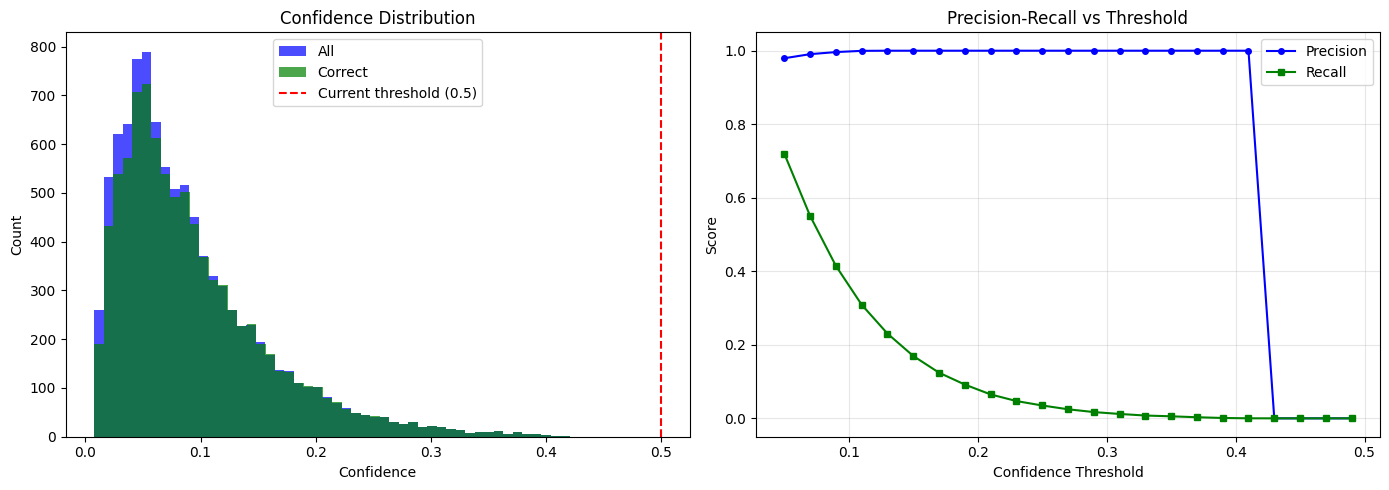

In [43]:


print("=" * 60)
print("PHÂN TÍCH CONFIDENCE DISTRIBUTION")
print("=" * 60)

# Thu thập tất cả confidence scores
all_confidences = []
all_correct = []

eval_model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_dataloader, desc="Analyzing"):
        images = images.to(device)
        outputs = eval_model(images)

        probs = outputs['pred_logits'].softmax(-1)[:, :, :-1]
        max_probs, pred_classes = probs.max(-1)
        pred_boxes = outputs['pred_boxes']

        for img_idx in range(images.shape[0]):
            gt_classes = targets[img_idx]['labels'].cpu().numpy()
            gt_boxes = targets[img_idx]['boxes'].cpu()
            gt_boxes = rescale_bboxes(gt_boxes, (224, 224)).numpy()

            # Lấy top prediction cho mỗi query
            img_probs = max_probs[img_idx].cpu().numpy()
            img_preds = pred_classes[img_idx].cpu().numpy()
            img_boxes = pred_boxes[img_idx].cpu()
            img_boxes = rescale_bboxes(img_boxes, (224, 224)).numpy()

            # Check từng prediction
            for prob, pred_cls, pred_box in zip(img_probs, img_preds, img_boxes):
                all_confidences.append(prob)

                # Check if correct (có match với GT không)
                is_correct = False
                for gt_cls, gt_box in zip(gt_classes, gt_boxes):
                    iou = compute_iou_single(pred_box, gt_box)
                    if iou >= 0.5 and pred_cls == gt_cls:
                        is_correct = True
                        break
                all_correct.append(is_correct)

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)

# Statistics
print(f"\n📈 CONFIDENCE STATISTICS (tất cả predictions):")
print(f"   • Mean confidence: {np.mean(all_confidences):.4f}")
print(f"   • Max confidence: {np.max(all_confidences):.4f}")
print(f"   • Min confidence: {np.min(all_confidences):.4f}")
print(f"   • Std: {np.std(all_confidences):.4f}")

# Confidence percentiles
print(f"\n📊 PERCENTILES:")
for p in [50, 75, 90, 95, 99]:
    print(f"   • {p}th percentile: {np.percentile(all_confidences, p):.4f}")

# Correct vs incorrect
correct_confs = all_confidences[all_correct]
incorrect_confs = all_confidences[~all_correct]

print(f"\n✅ CORRECT PREDICTIONS:")
if len(correct_confs) > 0:
    print(f"   • Count: {len(correct_confs)}")
    print(f"   • Mean confidence: {np.mean(correct_confs):.4f}")
    print(f"   • Max confidence: {np.max(correct_confs):.4f}")
else:
    print(f"   • Không có prediction nào correct với IoU >= 0.5")

print(f"\n❌ INCORRECT PREDICTIONS:")
print(f"   • Count: {len(incorrect_confs)}")
print(f"   • Mean confidence: {np.mean(incorrect_confs):.4f}")

# Recommend threshold
if len(correct_confs) > 0:
    recommended_threshold = np.percentile(correct_confs, 10)  # 10th percentile of correct
    print(f"\n💡 RECOMMENDED THRESHOLD: {recommended_threshold:.4f}")
else:
    print(f"\n⚠️ Model chưa học được - cần train thêm epochs!")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(all_confidences, bins=50, alpha=0.7, label='All', color='blue')
if len(correct_confs) > 0:
    ax1.hist(correct_confs, bins=50, alpha=0.7, label='Correct', color='green')
ax1.axvline(0.5, color='red', linestyle='--', label='Current threshold (0.5)')
ax1.set_xlabel('Confidence')
ax1.set_ylabel('Count')
ax1.set_title('Confidence Distribution')
ax1.legend()

# Precision-Recall at different thresholds
ax2 = axes[1]
thresholds = np.arange(0.05, 0.5, 0.02)
precisions = []
recalls = []

for t in thresholds:
    preds_above = all_confidences >= t
    if preds_above.sum() > 0:
        tp = (all_correct & preds_above).sum()
        fp = (~all_correct & preds_above).sum()
        fn = (all_correct & ~preds_above).sum()

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        prec, rec = 0, 0
    precisions.append(prec)
    recalls.append(rec)

ax2.plot(thresholds, precisions, 'b-o', label='Precision', markersize=4)
ax2.plot(thresholds, recalls, 'g-s', label='Recall', markersize=4)
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision-Recall vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)

📊 PHÂN TÍCH CONFIDENCE DISTRIBUTION


Analyzing: 100%|██████████| 3/3 [00:06<00:00,  2.14s/it]



📈 CONFIDENCE STATISTICS (tất cả predictions):
   • Mean confidence: 0.0910
   • Max confidence: 0.4207
   • Min confidence: 0.0075
   • Std: 0.0653

📊 PERCENTILES:
   • 50th percentile: 0.0733
   • 75th percentile: 0.1202
   • 90th percentile: 0.1797
   • 95th percentile: 0.2224
   • 99th percentile: 0.3144

✅ CORRECT PREDICTIONS:
   • Count: 9036
   • Mean confidence: 0.0943
   • Max confidence: 0.4207

❌ INCORRECT PREDICTIONS:
   • Count: 564
   • Mean confidence: 0.0373

💡 RECOMMENDED THRESHOLD: 0.0287


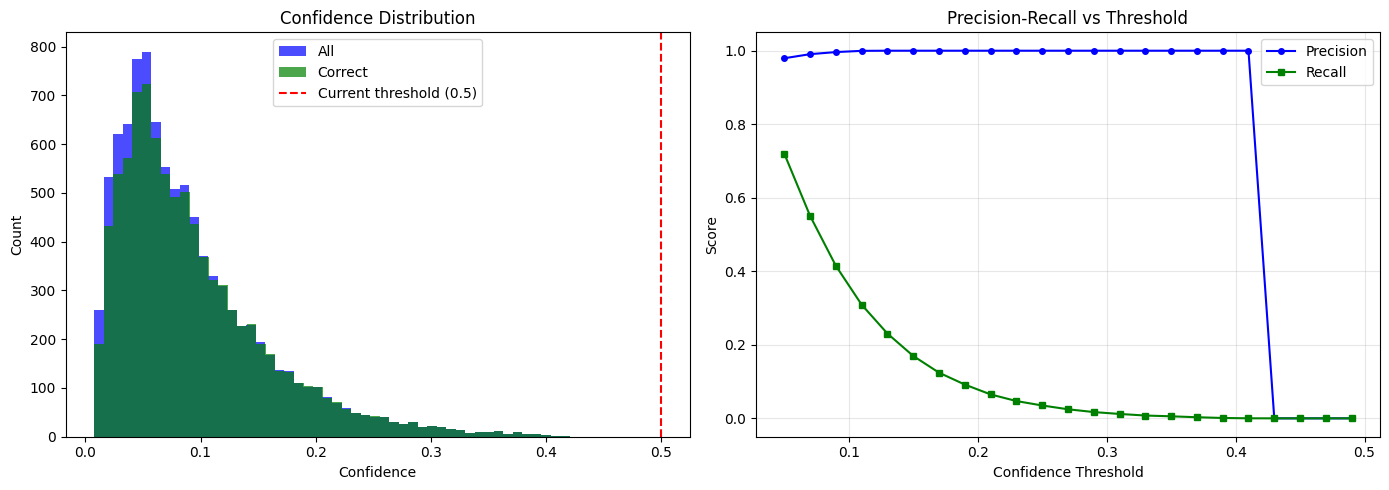

In [44]:


# Định nghĩa hàm compute_iou_single trước
def compute_iou_single(box1, box2):
    """Tính IoU giữa 2 boxes (format: xyxy)"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

print("=" * 60)
print("📊 PHÂN TÍCH CONFIDENCE DISTRIBUTION")
print("=" * 60)

# Thu thập tất cả confidence scores
all_confidences = []
all_correct = []

eval_model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_dataloader, desc="Analyzing"):
        images = images.to(device)
        outputs = eval_model(images)

        probs = outputs['pred_logits'].softmax(-1)[:, :, :-1]
        max_probs, pred_classes = probs.max(-1)
        pred_boxes = outputs['pred_boxes']

        for img_idx in range(images.shape[0]):
            gt_classes = targets[img_idx]['labels'].cpu().numpy()
            gt_boxes = targets[img_idx]['boxes'].cpu()
            gt_boxes = rescale_bboxes(gt_boxes, (224, 224)).numpy()

            # Lấy top prediction cho mỗi query
            img_probs = max_probs[img_idx].cpu().numpy()
            img_preds = pred_classes[img_idx].cpu().numpy()
            img_boxes = pred_boxes[img_idx].cpu()
            img_boxes = rescale_bboxes(img_boxes, (224, 224)).numpy()

            # Check từng prediction
            for prob, pred_cls, pred_box in zip(img_probs, img_preds, img_boxes):
                all_confidences.append(prob)

                # Check if correct (có match với GT không)
                is_correct = False
                for gt_cls, gt_box in zip(gt_classes, gt_boxes):
                    iou = compute_iou_single(pred_box, gt_box)
                    if iou >= 0.5 and pred_cls == gt_cls:
                        is_correct = True
                        break
                all_correct.append(is_correct)

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)

# Statistics
print(f"\n📈 CONFIDENCE STATISTICS (tất cả predictions):")
print(f"   • Mean confidence: {np.mean(all_confidences):.4f}")
print(f"   • Max confidence: {np.max(all_confidences):.4f}")
print(f"   • Min confidence: {np.min(all_confidences):.4f}")
print(f"   • Std: {np.std(all_confidences):.4f}")

# Confidence percentiles
print(f"\n📊 PERCENTILES:")
for p in [50, 75, 90, 95, 99]:
    print(f"   • {p}th percentile: {np.percentile(all_confidences, p):.4f}")

# Correct vs incorrect
correct_confs = all_confidences[all_correct]
incorrect_confs = all_confidences[~all_correct]

print(f"\n✅ CORRECT PREDICTIONS:")
if len(correct_confs) > 0:
    print(f"   • Count: {len(correct_confs)}")
    print(f"   • Mean confidence: {np.mean(correct_confs):.4f}")
    print(f"   • Max confidence: {np.max(correct_confs):.4f}")
else:
    print(f"   • Không có prediction nào correct với IoU >= 0.5")

print(f"\n❌ INCORRECT PREDICTIONS:")
print(f"   • Count: {len(incorrect_confs)}")
print(f"   • Mean confidence: {np.mean(incorrect_confs):.4f}")

# Recommend threshold
if len(correct_confs) > 0:
    recommended_threshold = np.percentile(correct_confs, 10)  # 10th percentile of correct
    print(f"\n💡 RECOMMENDED THRESHOLD: {recommended_threshold:.4f}")
else:
    print(f"\n⚠️ Model chưa học được tốt - cần train thêm epochs hoặc kiểm tra lại!")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(all_confidences, bins=50, alpha=0.7, label='All', color='blue')
if len(correct_confs) > 0:
    ax1.hist(correct_confs, bins=50, alpha=0.7, label='Correct', color='green')
ax1.axvline(0.5, color='red', linestyle='--', label='Current threshold (0.5)')
ax1.set_xlabel('Confidence')
ax1.set_ylabel('Count')
ax1.set_title('Confidence Distribution')
ax1.legend()

# Precision-Recall at different thresholds
ax2 = axes[1]
thresholds = np.arange(0.05, 0.5, 0.02)
precisions = []
recalls = []

for t in thresholds:
    preds_above = all_confidences >= t
    if preds_above.sum() > 0:
        tp = (all_correct & preds_above).sum()
        fp = (~all_correct & preds_above).sum()
        fn = (all_correct & ~preds_above).sum()

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        prec, rec = 0, 0
    precisions.append(prec)
    recalls.append(rec)

ax2.plot(thresholds, precisions, 'b-o', label='Precision', markersize=4)
ax2.plot(thresholds, recalls, 'g-s', label='Recall', markersize=4)
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision-Recall vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)

In [45]:


def compute_iou_single(box1, box2):
    """Tính IoU giữa 2 boxes (format: xyxy)"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def evaluate_model_full(model, dataloader, classes, device, conf_threshold=0.5, iou_threshold=0.5):
    """
    Đánh giá model với các metrics chi tiết
    """
    model.eval()

    all_pred_classes = []
    all_true_classes = []
    inference_times = []

    # Metrics theo class
    tp = defaultdict(int)  # True Positives
    fp = defaultdict(int)  # False Positives
    fn = defaultdict(int)  # False Negatives

    total_detections = 0
    correct_detections = 0

    print(f"\n🔄 Evaluating on {len(dataloader)} samples...")
    print(f"   Confidence threshold: {conf_threshold}")
    print(f"   IoU threshold: {iou_threshold}")
    print("-" * 50)

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(tqdm(dataloader, desc="Evaluating")):
            images = images.to(device)

            # Measure inference time
            start_time = time.perf_counter()
            outputs = model(images)
            inference_time = (time.perf_counter() - start_time) * 1000  # ms
            inference_times.append(inference_time)

            # Process predictions
            probabilities = outputs['pred_logits'].softmax(-1)[:, :, :-1]
            max_probs, pred_classes = probabilities.max(-1)
            pred_boxes = outputs['pred_boxes']

            # Process each image in batch
            for img_idx in range(images.shape[0]):
                # Get predictions above threshold
                keep_mask = max_probs[img_idx] > conf_threshold

                img_pred_classes = pred_classes[img_idx][keep_mask].cpu().numpy()
                img_pred_probs = max_probs[img_idx][keep_mask].cpu().numpy()
                img_pred_boxes = pred_boxes[img_idx][keep_mask].cpu()

                # Convert boxes to xyxy format and scale
                img_pred_boxes = rescale_bboxes(img_pred_boxes, (224, 224)).numpy()

                # Get ground truth
                gt_classes = targets[img_idx]['labels'].cpu().numpy()
                gt_boxes = targets[img_idx]['boxes'].cpu()
                gt_boxes = rescale_bboxes(gt_boxes, (224, 224)).numpy()

                # Track which GT boxes have been matched
                matched_gt = set()

                # Match predictions to ground truth
                for pred_idx, (pred_cls, pred_conf, pred_box) in enumerate(
                    zip(img_pred_classes, img_pred_probs, img_pred_boxes)):

                    best_iou = 0
                    best_gt_idx = -1

                    # Find best matching GT box
                    for gt_idx, (gt_cls, gt_box) in enumerate(zip(gt_classes, gt_boxes)):
                        if gt_idx in matched_gt:
                            continue

                        iou = compute_iou_single(pred_box, gt_box)
                        if iou > best_iou and pred_cls == gt_cls:
                            best_iou = iou
                            best_gt_idx = gt_idx

                    # If IoU > threshold and class matches -> True Positive
                    if best_iou >= iou_threshold and best_gt_idx >= 0:
                        matched_gt.add(best_gt_idx)
                        tp[pred_cls] += 1
                        all_pred_classes.append(pred_cls)
                        all_true_classes.append(pred_cls)
                        correct_detections += 1
                    else:
                        # False Positive
                        fp[pred_cls] += 1
                        all_pred_classes.append(pred_cls)
                        if len(gt_classes) > 0:
                            all_true_classes.append(gt_classes[0])
                        else:
                            all_true_classes.append(-1)

                    total_detections += 1

                # Unmatched GT boxes -> False Negatives
                for gt_idx, gt_cls in enumerate(gt_classes):
                    if gt_idx not in matched_gt:
                        fn[gt_cls] += 1

    return {
        'pred_classes': all_pred_classes,
        'true_classes': all_true_classes,
        'inference_times': inference_times,
        'tp': dict(tp),
        'fp': dict(fp),
        'fn': dict(fn),
        'total_detections': total_detections,
        'correct_detections': correct_detections
    }


print("\n" + "=" * 60)
print("🔍 STARTING MODEL EVALUATION")
print("=" * 60)

# Chạy evaluation với confidence threshold = 0.5
eval_results = evaluate_model_full(
    eval_model,
    test_dataloader,
    CLASSES,
    device,
    conf_threshold=0.5,
    iou_threshold=0.5
)

print("\n✅ Evaluation complete!")


🔍 STARTING MODEL EVALUATION

🔄 Evaluating on 3 samples...
   Confidence threshold: 0.5
   IoU threshold: 0.5
--------------------------------------------------


Evaluating: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it]


✅ Evaluation complete!


In [47]:


print("=" * 70)
print("🎯 ACCURACY METRICS")
print("=" * 70)

# 1. Classification Accuracy: Lấy top-1 prediction cho mỗi ảnh, so với GT
# (Không xét bounding box, chỉ xét class prediction)

correct_classifications = 0
total_images = 0

# 2. Detection Accuracy: Prediction đúng class VÀ IoU > 0.5
correct_detections = 0
total_gt_objects = 0

eval_model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_dataloader, desc="Computing Accuracy"):
        images = images.to(device)
        outputs = eval_model(images)

        probs = outputs['pred_logits'].softmax(-1)[:, :, :-1]
        max_probs, pred_classes = probs.max(-1)
        pred_boxes = outputs['pred_boxes']

        for img_idx in range(images.shape[0]):
            gt_classes = targets[img_idx]['labels'].cpu().numpy()
            gt_boxes = targets[img_idx]['boxes'].cpu()
            gt_boxes_scaled = rescale_bboxes(gt_boxes, (224, 224)).numpy()

            # ===== 1. Classification Accuracy (Top-1 per image) =====
            # Lấy prediction có confidence cao nhất
            best_query_idx = max_probs[img_idx].argmax()
            top1_pred_class = pred_classes[img_idx][best_query_idx].item()
            top1_confidence = max_probs[img_idx][best_query_idx].item()


            if len(gt_classes) > 0:
                if top1_pred_class == gt_classes[0]:
                    correct_classifications += 1
                total_images += 1

            # ===== 2. Detection Accuracy (Class + IoU) =====
            img_pred_boxes = pred_boxes[img_idx].cpu()
            img_pred_boxes_scaled = rescale_bboxes(img_pred_boxes, (224, 224)).numpy()
            img_pred_classes = pred_classes[img_idx].cpu().numpy()
            img_pred_probs = max_probs[img_idx].cpu().numpy()

            matched_gt = set()

            for gt_idx, (gt_cls, gt_box) in enumerate(zip(gt_classes, gt_boxes_scaled)):
                total_gt_objects += 1

                # Tìm prediction tốt nhất cho GT này
                best_iou = 0
                best_pred_idx = -1

                for pred_idx, (pred_cls, pred_box) in enumerate(zip(img_pred_classes, img_pred_boxes_scaled)):
                    if pred_cls != gt_cls:
                        continue
                    iou = compute_iou_single(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_pred_idx = pred_idx

                if best_iou >= 0.5 and best_pred_idx >= 0:
                    correct_detections += 1

# KẾT QUẢ


classification_accuracy = correct_classifications / total_images if total_images > 0 else 0
detection_accuracy = correct_detections / total_gt_objects if total_gt_objects > 0 else 0

print(f"\n📊 CLASSIFICATION ACCURACY (Top-1 per image):")
print(f"   • Correct: {correct_classifications}/{total_images}")
print(f"   • Accuracy: {classification_accuracy:.4f} ({classification_accuracy*100:.2f}%)")

print(f"\n📊 DETECTION ACCURACY (Class match + IoU >= 0.5):")
print(f"   • Correct: {correct_detections}/{total_gt_objects}")
print(f"   • Accuracy: {detection_accuracy:.4f} ({detection_accuracy*100:.2f}%)")

# ============================================================================
# TOP-K ACCURACY
# ============================================================================
print(f"\n📊 TOP-K CLASSIFICATION ACCURACY:")

for k in [1, 3, 5]:
    correct_topk = 0
    total_topk = 0

    with torch.no_grad():
        for images, targets in test_dataloader:
            images = images.to(device)
            outputs = eval_model(images)

            probs = outputs['pred_logits'].softmax(-1)[:, :, :-1]

            for img_idx in range(images.shape[0]):
                gt_classes = targets[img_idx]['labels'].cpu().numpy()

                if len(gt_classes) == 0:
                    continue

                # Lấy top-k predictions (theo confidence cao nhất từ tất cả queries)
                img_probs = probs[img_idx]  # [num_queries, num_classes]
                max_probs_per_query, pred_classes_per_query = img_probs.max(-1)

                # Sort theo confidence và lấy top-k
                topk_indices = max_probs_per_query.topk(min(k, len(max_probs_per_query)))[1]
                topk_classes = pred_classes_per_query[topk_indices].cpu().numpy()

                # Check nếu GT class nằm trong top-k
                gt_class = gt_classes[0]  # Lấy GT đầu tiên
                if gt_class in topk_classes:
                    correct_topk += 1
                total_topk += 1

    topk_accuracy = correct_topk / total_topk if total_topk > 0 else 0
    print(f"   • Top-{k} Accuracy: {topk_accuracy:.4f} ({topk_accuracy*100:.2f}%)")

print("=" * 70)

🎯 ACCURACY METRICS


Computing Accuracy: 100%|██████████| 3/3 [00:07<00:00,  2.59s/it]



📊 CLASSIFICATION ACCURACY (Top-1 per image):
   • Correct: 382/384
   • Accuracy: 0.9948 (99.48%)

📊 DETECTION ACCURACY (Class match + IoU >= 0.5):
   • Correct: 384/384
   • Accuracy: 1.0000 (100.00%)

📊 TOP-K CLASSIFICATION ACCURACY:
   • Top-1 Accuracy: 0.9948 (99.48%)
   • Top-3 Accuracy: 0.9948 (99.48%)
   • Top-5 Accuracy: 0.9948 (99.48%)
